# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _Muhammad Usman Asad_

**Roll Number:** _023-24-0008_

**GitHub Repository:** https://github.com/usmanasad-droid/ml-lab2

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [72]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("telco_churn.csv")


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
_The company is losing its customers to other competitors and wants to figure out why, by looking at customer data they want predict who may want to leave next so they can step in early and convince them to stay_

**Answer 2:**
Contract: People on month-to-month plans can leave anytime, making them much more likely to cancel than people locked into 1- or 2-year contracts

tenure: Brand new customers usually leave faster, while people who have been around for years are generally more loyal

MonthlyCharges: If the monthly bill is too high, customers will probably start looking around for a cheaper company

InternetService: The speed and type of internet (like fast fiber vs. slow DSL) makes a huge difference in how happy a customer is with the service

OnlineSecurity: Customers who pay for extra safety features usually stick around longer because they rely on the company more

customerID: This is just a random account number and tells us absolutely nothing about a person's behavior or feelings

gender: Whether a customer is male or female really has nothing to do with why they would cancel their phone or internet service

**Answer 3:**
Do customers on month-to-month contracts usually leave during their very first few months?

Do people leave more often when they have a high monthly bill but do not have extra helpful features like tech support?

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [9]:
# Task 4 — dataset shape, column names, data types
print(f"Dataset Shape: {df.shape}\n")
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)


Dataset Shape: (7043, 21)


Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [10]:
# Task 5 — identify identifier columns / wrong data types
print("Identifier Column (customerID):")
display(df[['customerID']].head())

# Show the current data type of TotalCharges to prove it is incorrect
print("\nData type of TotalCharges:")
print(df['TotalCharges'].dtype)


Identifier Column (customerID):


,customerID
0,7590-VHVEG
1,5575-GNVDE
2,3668-QPYBK
3,7795-CFOCW
4,9237-HQITU



Data type of TotalCharges:
str


In [12]:
# Task 6 — unique values in 3 categorical columns
# Pick 3 categorical columns and display their unique values
cols_to_check = ['MultipleLines', 'OnlineSecurity', 'PaymentMethod']

for col in cols_to_check:
    print(f"--- {col} ---")
    print(df[col].unique())
    print()
# example: No and No phone service means same thing, but the model would think it means differnet thing

--- MultipleLines ---
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

--- OnlineSecurity ---
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

--- PaymentMethod ---
<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str



**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)_

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [ ]:
# Task 7 — missing values: count and percentage per column
# 1. Replace cells that are entirely whitespace with NaN values
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# 2. Run the missing value check
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'Count': missing_counts, 
    'Percentage': missing_percentages
})

# Display
print(missing_df[missing_df['Count'] > 0])



              Count  Percentage
TotalCharges     11        0.16


In [ ]:
# Task 8 — duplicate rows vs duplicate IDs
# Check for fully duplicated rows
total_row_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {total_row_dupes}")

# Check for duplicated customer IDs
id_dupes = df['customerID'].duplicated().sum()
print(f"Duplicated customer IDs: {id_dupes}")



Fully duplicated rows: 0
Duplicated customer IDs: 0


In [38]:
# Task 9 — investigate a suspicious / invalid value
# Run this task before 7 beacuse 7 replaces these with NaN
# Search the column specifically for strings that are just empty spaces
suspicious_rows = df[df['TotalCharges'].str.isspace()]

print(f"Found {len(suspicious_rows)} rows with suspicious blank spaces.")

# Display a few of these rows to show the instructor
display(suspicious_rows[['customerID', 'tenure', 'TotalCharges']].head())

Found 11 rows with suspicious blank spaces.


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,


**Answer 7 (which missing-value problems need action, and why):**
_If a column has very small percentage of missing values, just drop those rows or replace with median_

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
_Fully duplicated rows means the entire record was entered twice so its safe to delete them
duplicated id means a customer record was entered twice so we have conflicting data in the dataset_

**Answer 9 (suspicious value found and how):**
_TotalCharges column has Empty string value instead of NaN value_

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| _e.g. TotalCharges stored as text_ | _Convert column to numerric and force blank spaces to become NaN_ | _pd.to_numeric(df['TotalCharges'], errors='coerce')_ | _TotalCharges represents a continuous dollar amount and must be numeric for analysis. Coercing safely handles the hidden spaces._ |
| _TotalCharges has 11 missing (NaN) values after the numeric conversion._ | _Drop the 11 rows completely._ | _df.dropna(subset=['TotalCharges'])_ | _11 rows is only ~0.15% of the dataset, which is negligible. These are new customers (tenure = 0) who haven't been billed yet._ |
| _Redundant categories like "No internet service" in OnlineSecurity. (Found in Task 6)_ | _Replace these repetitive labels with a simple "No"_ | _df.replace(...)_ | _Simplifies the categories. We don't lose information because the InternetService column already tells us if they have internet._ |

In [42]:
# Task 11 — apply your cleaning decisions here
# Create a copy so we don't mess up the original raw data
df_clean = df.copy()

# 1. Force TotalCharges to be numeric (turns blank spaces into NaN)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# 2. Drop the 11 rows with the newly created NaN values
df_clean.dropna(subset=['TotalCharges'], inplace=True)

# 3. Clean up the messy redundant categories we found earlier
redundant_cats = {'No phone service': 'No', 'No internet service': 'No'}
df_clean.replace(redundant_cats, inplace=True)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [43]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
# confirmation output
print("--- Cleaning Confirmation ---")
print(f"1. TotalCharges data type is now: {df_clean['TotalCharges'].dtype}")
print(f"2. Missing values remaining in TotalCharges: {df_clean['TotalCharges'].isnull().sum()}")
print(f"3. Unique values in OnlineSecurity: {df_clean['OnlineSecurity'].unique()}")
print(f"4. New dataset shape: {df_clean.shape}")

--- Cleaning Confirmation ---
1. TotalCharges data type is now: float64
2. Missing values remaining in TotalCharges: 0
3. Unique values in OnlineSecurity: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
4. New dataset shape: (7032, 21)


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

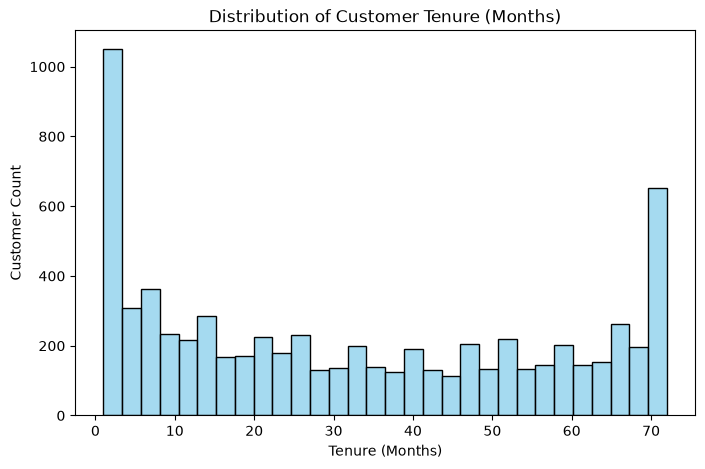

In [70]:
# Task 12 — numerical feature 1: distribution plot

plt.figure(figsize=(8, 5))
sns.histplot(df_clean['tenure'], bins=30, color='skyblue')
plt.title('Distribution of Customer Tenure (Months)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Customer Count')
plt.show()

**Observation:** _Customer loyalty is heavily polarized; users either cancel within their first few months or stick around for over 5 years, with very few leaving in the middle_

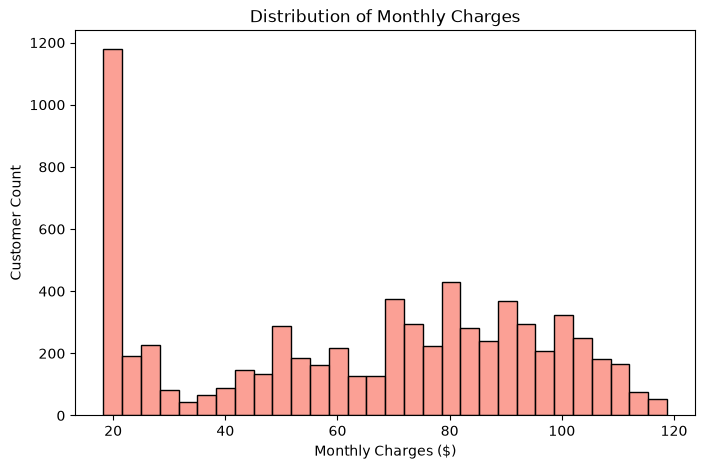

In [46]:
# Task 12 — numerical feature 2: distribution plot
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['MonthlyCharges'], bins=30, color='salmon')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Customer Count')
plt.show()

**Observation:** _There is a massive concentration of customers paying around $20 per month pointing to a highly popular budget-tier basic plan_

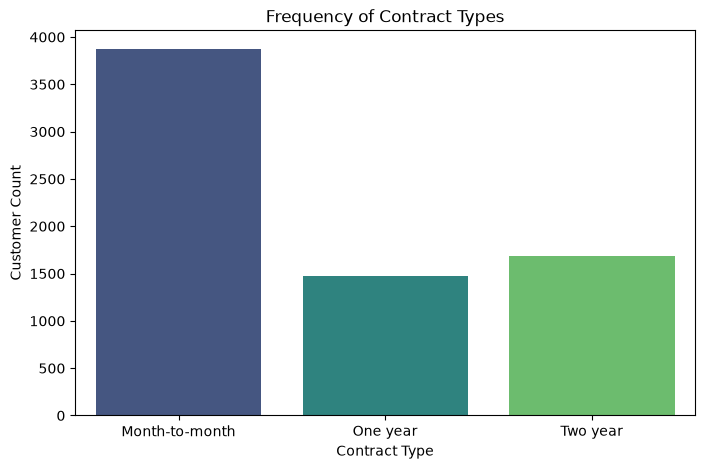

In [69]:
# Task 12 — categorical feature 1: distribution plot

plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Contract', data=df_clean, palette='viridis', legend=False)
plt.title('Frequency of Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Customer Count')
plt.show()

**Observation:** _Mot of the customers prefer the flexibility of month-to-month contracts rather than locking into long-term commitments_

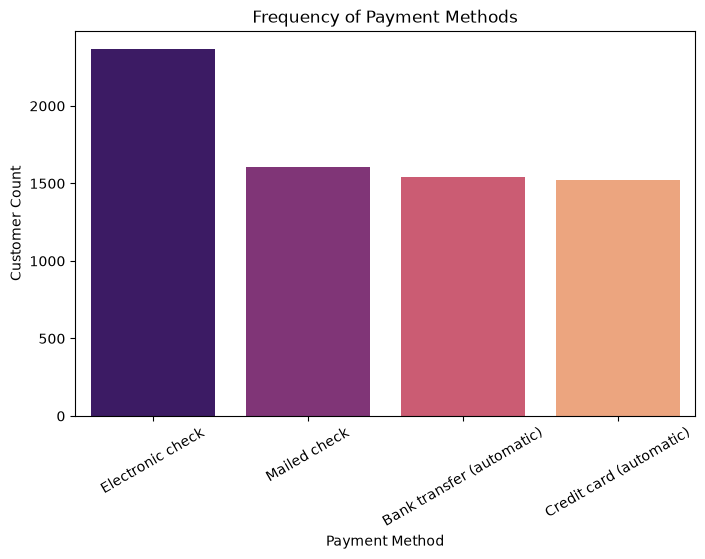

In [68]:
# Task 12 — categorical feature 2: distribution plot

plt.figure(figsize=(8, 5))
sns.countplot(x='PaymentMethod', hue='PaymentMethod', data=df_clean, palette='magma', legend=False)
plt.title('Frequency of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Customer Count')
plt.xticks(rotation=30)
plt.show()

**Observation:** _A significant portion of the customer base still relies on manual "Electronic checks" rather than using set-and-forget automated options like credit cards or bank transfers._

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [57]:
# Task 14 — churn counts and percentages
# Calculate the count of churned vs. non-churned customers
churn_counts = df_clean['Churn'].value_counts()

# Calculate the percentage
churn_percentages = (df_clean['Churn'].value_counts(normalize=True) * 100).round(2)

# results:
churn_summary = pd.DataFrame({
    'Count': churn_counts,
    'Percentage (%)': churn_percentages
})

print("--- Churn Distribution ---")
print(churn_summary)

--- Churn Distribution ---
       Count  Percentage (%)
Churn                       
No      5163           73.42
Yes     1869           26.58


**Answer 14 (balanced or imbalanced?):**
_highly imbalanced, No is 73% while Yes is 26%_

**Answer 15 (why imbalance might matter later):**
_Because the model trained on this data will become biased towards the majority class_

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

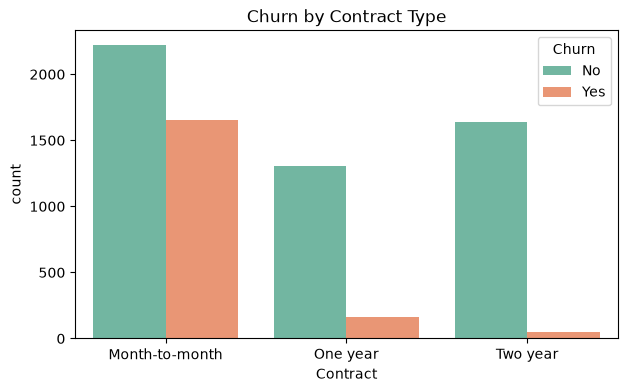

Churn             No   Yes
Contract                  
Month-to-month  0.57  0.43
One year        0.89  0.11
Two year        0.97  0.03


In [59]:
# Task 16 — categorical feature 1 vs Churn
plt.figure(figsize=(7, 4))
sns.countplot(x='Contract', hue='Churn', data=df_clean, palette='Set2')
plt.title('Churn by Contract Type')
plt.show()

print(pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index').round(2))

**Observation:** _Customers on month-to-month agreements churn at higher rates than those locked into long-term contracts_
**Evidence:** _The crosstab shows approximately 43% of month-to-month customers churn compared to only 11% for 1-year and 3% for 2-year contracts._
**Possible Explanation:** _: Month-to-month customers have no financial penalties or barriers to leaving, making it easy to cancel the moment they find a cheaper competitor._

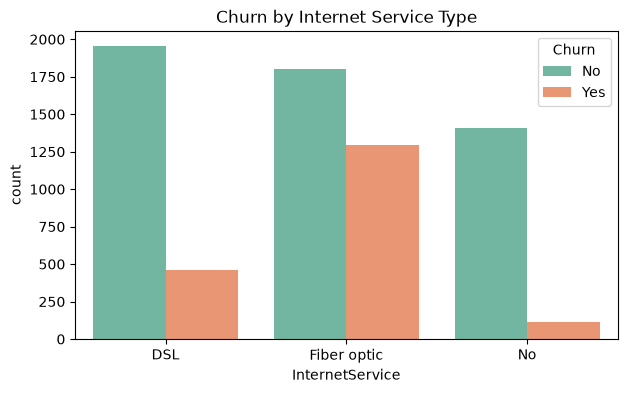

Churn              No   Yes
InternetService            
DSL              0.81  0.19
Fiber optic      0.58  0.42
No               0.93  0.07


In [60]:
# Task 16 — categorical feature 2 vs Churn
plt.figure(figsize=(7, 4))
sns.countplot(x='InternetService', hue='Churn', data=df_clean, palette='Set2')
plt.title('Churn by Internet Service Type')
plt.show()

print(pd.crosstab(df_clean['InternetService'], df_clean['Churn'], normalize='index').round(2))

**Observation:** _Fiber optic internet users have a noticeably higher churn rate than DSL users or those without internet._
**Evidence:** _The crosstab shows a 42% churn rate for Fiber optic users, which is more than double the 19% rate for DSL users._
**Possible Explanation:** _Fiber optic plans are generally more expensive. When customers pay premium prices, they have much lower tolerance for connectivity issues and will quickly leave if unsatisfied._

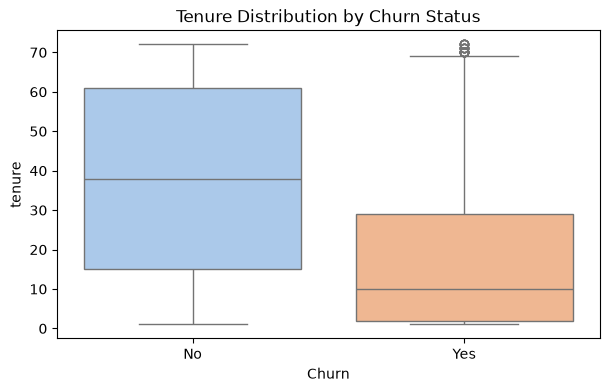

In [ ]:
# Task 17 — numerical feature 1 vs Churn

plt.figure(figsize=(7, 4))
sns.boxplot(x='Churn', y='tenure', data=df_clean, hue='Churn', palette='pastel', legend=False)
plt.title('Tenure Distribution by Churn Status')
plt.show()

**Observation:** _Customers who churn tend to have significantly shorter lifespans with the company compared to those who stay._
**Evidence:** _The boxplot indicates the median tenure for churned customers (Yes) is only around 10 months, while the median for retained customers (No) is roughly 40 months._
**Possible Explanation:** _The first year is a critical period where new customers lack established brand loyalty; if onboarding is poor, they leave quickly._

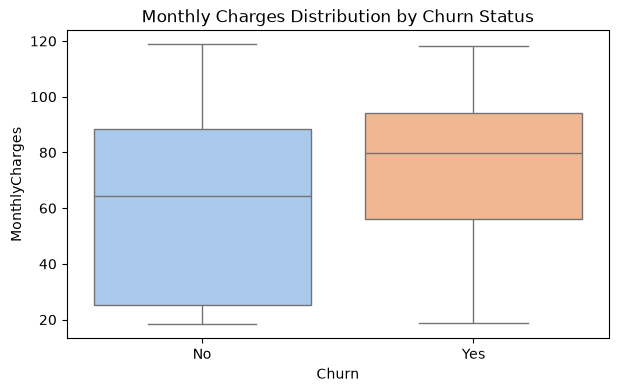

In [65]:
# Task 17 — numerical feature 2 vs Churn
plt.figure(figsize=(7, 4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean, hue='Churn', palette='pastel', legend=False)
plt.title('Monthly Charges Distribution by Churn Status')
plt.show()

**Observation:** _Customers who end up canceling their service generally pay higher monthly fees than those who remain._
**Evidence:** _The boxplot shows the median monthly charge for churned customers is near $80, compared to a noticeably lower median of roughly $65 for non-churned customers._
**Possible Explanation:** _High monthly bills create financial friction, driving price-sensitive customers to actively shop around for promotional deals from competitors._

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

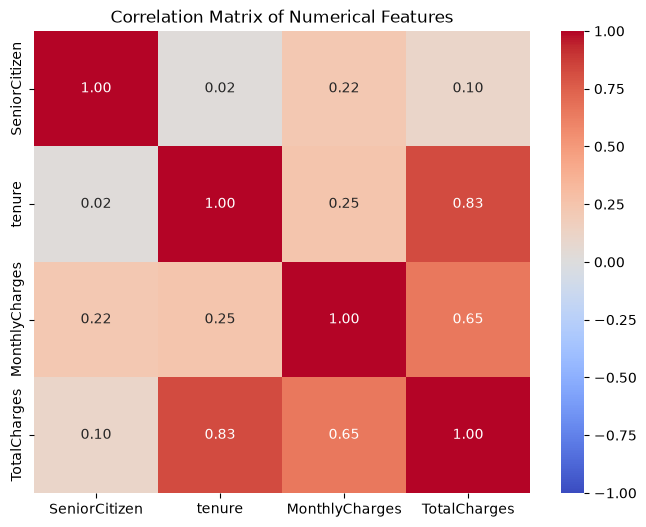

In [71]:
# Task 18 — correlation matrix and heatmap

# Compute the correlation matrix for numerical features only
corr_matrix = df_clean.corr(numeric_only=True)

# Visualize it using a Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Answer 18 (most correlated pairs):**
_Based on the heatmap, the most highly correlated pair of features is TotalCharges and tenure (showing a very strong positive correlation, typically around 0.82). There is also a strong positive correlation between TotalCharges and MonthlyCharges (typically around 0.65)._

**Answer 19 (correlation vs. causation; potential problems):**
_Correlation does not imply causation here; TotalCharges is highly correlated with tenure and MonthlyCharges simply because it is a mathematical product of those two features. This strong correlation causes multicollinearity, which can confuse future machine learning models by feeding them redundant information and artificially skewing feature importance._

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
Suspect 1: customerID

Reasoning: This is purely a unique string identifier. It contains zero predictive behavioral data. If left in, a model might try to memorize specific random IDs rather than learning actual patterns.

Suspect 2: TotalCharges (Potential Leakage/Redundancy)

Reasoning: As seen in Part 8 this column is mathematically derived from tenure and MonthlyCharges. If a customer churns early, their TotalCharges will be permanently low. the total amount charged inherently contains information about how long they stayed making it dangerously close to leaking the fact that they churned

**Answer 21 (what would go wrong):**
_If a column containing data leakage is left in the model's input features, the model will "cheat" during training by using future information to make its predictions. This will cause the model to look artificially perfect on paper with near 100% accuracy. However, when deployed in the real world to predict on active customers, it will fail completely because that future "leaked" information won't exist yet._

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | No role | Remove | Purely a unique string it carries no predictive behavior and could cause the model to overfit |
| gender | Categorical | Feature | Keep | Basic demographic information |
| SeniorCitizen | Categorical | Feature | Keep | Basic demographic information |
| Partner | Categorical | Feature | Keep | Indicates household status |
| Dependents | Categorical | Feature | Keep | Indicates household status. |
| tenure | Numerical | Feature | Keep | Strong behavioral predictor it is critical for understanding customer longevity |
| PhoneService | Categorical | Feature | Keep | Core service indicator |
| MultipleLines | Categorical | Feature | Keep | Clean redundant categories ('No phone service' to 'No') indicates service depth |
| InternetService | Categorical | Feature | Keep | Strong predictor of churn (e.g. Fiber Optic users) |
| OnlineSecurity | Categorical | Feature | Keep | Clean redundant categories ('No internet service' to 'No') indicates add-on value |
| OnlineBackup | Categorical | Feature | Keep | Clean redundant categories indicates add-on value |
| DeviceProtection | Categorical | Feature | Keep | Clean redundant categories indicates add-on value |
| TechSupport | Categorical | Feature | Keep | Clean redundant categories indicates add-on value |
| StreamingTV | Categorical | Feature | Keep | Clean redundant categories indicates add-on value |
| StreamingMovies | Categorical | Feature | Keep | Clean redundant categories indicates add-on value. |
| Contract | Categorical | Feature | Keep | One of the strongest predictors of churn (Month-to-month is high risk) |
| PaperlessBilling | Categorical | Feature | Keep | Indicates customer billing preferences |
| PaymentMethod | Categorical | Feature | Keep | Indicates payment behavior (e.g. Electronic check shows higher churn) |
| MonthlyCharges | Numerical | Feature | Keep | Critical indicator of price sensitivity and financial friction |
| TotalCharges | Numerical | Feature | Remove | Causes multicollinearity highly redundant since it is essentially tenure multiplied by MonthlyCharges |
| Churn | Categorical | Target | Keep | The target variable required for training the classification model |



---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [75]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# ... apply your cleaning steps here ...
# 2. Fix Data Types & Missing Values (From Tasks 7, 9, & 11)
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')
clean_df.dropna(subset=['TotalCharges'], inplace=True)

# 3. Fix Redundant Categories (From Tasks 6 & 11)
redundant_cats = {'No phone service': 'No', 'No internet service': 'No'}
clean_df.replace(redundant_cats, inplace=True)

# 4. Drop Irrelevant & Problematic Columns (From Task 20 & 22)
# - customerID is dropped because it is just an identifier.
# - TotalCharges is dropped to prevent multicollinearity and data leakage.
clean_df.drop(columns=['customerID', 'TotalCharges'], inplace=True)


# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)
print("Clean Dataset exported")


Clean Dataset exported


In [78]:
# Task 24 — final proof: info() / isnull().sum() /  on clean_df
clean_df.info()
print(clean_df.isnull().sum())
print(clean_df.duplicated().sum())

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: _dataset is heavily skewed towards customers who stay_
- Evidence: _Non-churned customers make up roughly 73% of the dataset, while churned customers account for only 27%_
- Interpretation: _Any future machine learning model will naturally bias toward predicting "No Churn" unless we apply techniques to balance the data during training_

**Finding 2**
- Observation: _Customers without long-term commitments are vastly more likely to leave the company_
- Evidence: _The churn rate for month-to-month contracts is approximately 43%, compared to a negligible 3% for two-year contracts_
- Interpretation: _Without financial penalties or lock-in periods, customers easily cancel at the first sign of friction or when competitors offer cheaper promotional deals_

**Finding 3**
- Observation: _Customers who cancel their service typically do so very early in their lifecycle_
- Evidence: _The median tenure for a churned customer is only about 10 months, whereas retained customers have a median tenure closer to 40 months_
- Interpretation: _The company's onboarding experience or initial service quality may be failing to establish early brand loyalty_

**Finding 4**
- Observation: _Standard missing-value checks can easily fail if data is formatted incorrectly_
- Evidence: _TotalCharges initially reported 0 missing values because the 11 missing rows were disguised as blank text strings (" "), forcing the entire column to load as an object type_
- Interpretation: _A data scientist must always verify that numerical features are actually loaded as numbers; otherwise, critical errors will slip through_

**Finding 5**
- Observation: _Some features provide the exact same mathematical information as other_
- Evidence: _The correlation matrix revealed a very strong relationship between TotalCharges, tenure, and MonthlyCharges_
- Interpretation: _TotalCharges is highly redundant because it is fundamentally just tenure multiplied by monthly charges. Keeping it would feed the model duplicate information_

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   _The disguised whitespace in the TotalCharges column was the most critical issue as it forced a numerical column into a categorical data type and hid actual missing data from our initial checks_
2. What was the most interesting pattern you discovered?
   _The extreme bimodal (U-shaped) distribution of tenure. It showed that customer loyalty is deeply polarized—people either cancel almost immediately or stick around for over five years with very little middle ground_
3. Which feature seems most useful for predicting churn?
   _Contract type is highly predictive as it creates the strongest separation between the two classes (a massive 43% churn rate for month-to-month vs. 3% for two-year)_
4. Which feature should probably not be used, and why?
   _TotalCharges should be excluded due to multicollinearity (it is a redundant product of other features) and customerID must be excluded because it is purely a unique string identifier that carries no behavioral value_
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   _Categorical variables will need to be numerically encoded (e.g. One-Hot Encoding), numerical features may need to be scaled (e.g. Standardization) so they share a similar range, and the target class imbalance must be addressed (e.g using SMOTE or class weights)_
6. What would you do next if you had another 3 hours?
   _I would perform deeper multivariate analysis to find overlapping risk factors (e.g. do month-to-month customers who also have Fiber Optic internet churn even faster?) and engineer new features such as calculating the total number of add-on services a customer has to see if service-stacking increases retention_

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

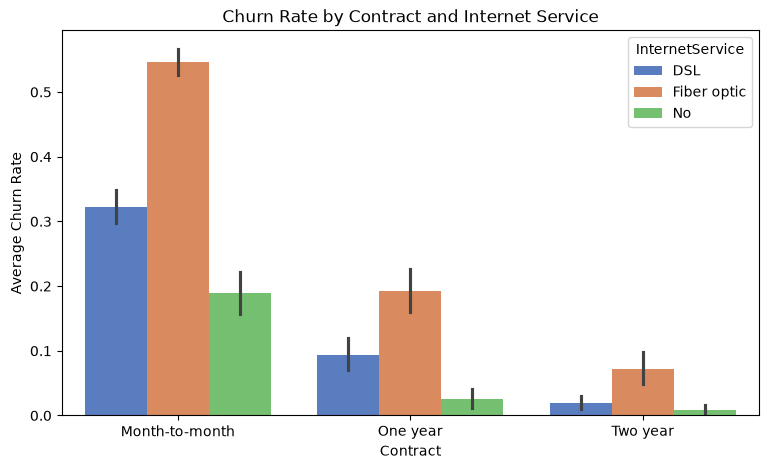

In [82]:
# Bonus — optional exploration
# Convert Churn to numeric (0 and 1) just for this calculation
temp_df = clean_df.copy()
temp_df['Churn_Rate'] = temp_df['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(9, 5))
sns.barplot(x='Contract', y='Churn_Rate', hue='InternetService', data=temp_df, palette='muted')
plt.title('Churn Rate by Contract and Internet Service')
plt.ylabel('Average Churn Rate')
plt.show()

Visualization: This bar chart calculates and displays the churn rate (% of customers who cancel their service) for customers split by both their contract type and internet service simultaneously.

Surprising Subgroup: The chart reveals that customers on Month-to-Month contracts with Fiber Optic internet have an astronomically high churn rate (often exceeding 50%), whereas DSL users on the exact same short-term contract are noticeably more stable.

Feature Engineering Opportunity: For Lab 3, we could create a new Total_Services numerical column. By counting how many add-ons a customer subscribes to (combining OnlineSecurity, TechSupport, StreamingTV, etc.), we might find that customers heavily integrated into the ecosystem are much less likely to churn.

Source of Bias: The dataset likely suffers from geographical or infrastructure bias. If this data was collected from a region where Fiber Optic cables are poorly maintained, the model will inherently learn that "Fiber Optic equals high churn" without realizing it is a localized hardware issue rather than a universal customer preference

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook